In [1]:
import pandas as pd
import numpy as np


## Limpieza de la Base Selva Viva



In [2]:
named13C_cellulose = "δ13C (‰ v.s.V-PDB)"
named13C_bulk = "bulk_δ13C (‰ v.s.V-PDB)"
name18O = "δ18O in ‰ vs DeltaSMOW"
named15N = "δ15N (‰ v.s. V-PDB)"
nameC_bulk ="[C_b]%"
nameC_cellulose = "[C]%"
thick = "mean_thickness_(mm)"
though = "mean_toughness_(kN/m)"
LA = "Leaf area (cm²)"
name = "genus" + "especie"

In [3]:
rasgos_2024 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Selva Viva\04. Rasgos_SelvaViva.xlsx")
#cambiar nombres de columnas para que quede bien 
rasgos_2024 = rasgos_2024[["#","Plot_code","TreeID_2025"]] #this one does not have the old ID.
rasgos_2025 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Selva Viva\Base_SelvaViva v2.xlsx",sheet_name="Rasgos")
rasgos_2025 = rasgos_2025[["PlotID","treeID","new ID 2024"]]
rasgos_2025 = rasgos_2025.rename(columns = {"new ID 2024": "TreeID_2025","PlotID":"Plot_code"})
rasgos = pd.concat([rasgos_2024,rasgos_2025])
#rasgos.to_excel("test.xlsx")
#en rasgos solo mantener las columnas de los rasgos. 

In [4]:
#rasgos = rasgos.rename(columns={"#":"Plot", "TreeID_2025":"TreeID"}) #Nunca usar Familia y genus de este.
#rasgos.head(3)
#possible errores por nombres antiguos. Reeplace first usando la del 2025 en las bases.

In [5]:
#base grande = pd.read_excel("XXXX base datos")
#merge = pd.merge(base_grande, rasgos, how="outer", left_on = ["new ID 2024","Plot"],right_on= ["TreeID","Plot"])
#merge = merge[merge["PlotID"].isin([
#    "GAL_22", "GAL_23", "GAL_24", "GAL_28"
#])] #filtra los censados. GAL 29 no hecha pero hay del 2006

In [6]:
#CELLULOSA
celulosa = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Selva Viva\resultados072025.xlsx")

patrones = ["p68","p69","p70","p72","p74"] #Los de Selva Viva censados
df_filtrado = celulosa[celulosa["Sample ID"].str.contains("|".join(patrones), na=False)]

df_filtrado= df_filtrado.rename(columns={"Sample ID":"Sample-ID","Meas batch":"Batch"})#arriba todo con guion


## arreglando typos
#df_filtrado["Sample ID"] = df_filtrado["Sample ID"].replace({
#    "p28-8974": "p23-8974"

df_filtrado["Year"] = np.select(
    [
        df_filtrado["Batch"].str.contains("NAPO2006", na=False),
        df_filtrado["Batch"].str.contains("NUMEX", na=False), #caso especial
        df_filtrado["Batch"].str.contains("NAPO2025", na=False),
    ],
    [2006,2025,2025],
    default=np.nan
)

#HELP: La idea es filtrar y luego de filtrar por año se puede unir por ID 2025 o ID original
df_filtrado[["Plot","new_TreeID"]] = df_filtrado["Sample-ID"].str.split("-",expand=True)
df_filtrado["Type"] = "leaf pulverized"
df_filtrado["Plot"]= df_filtrado["Plot"].str.replace("p","")
df_filtrado = df_filtrado.rename(columns = {"δ15N (‰ v.s. AIR)":named13C_cellulose,"[C] in %":nameC_cellulose})

print("Resultados de Celulosa")
len(df_filtrado) #78


Resultados de Celulosa


43

# Celulosa de muestras de herbario y muestras enero 2026.

In [7]:
nameC_cellulose = "[C]%"

cel2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea-Cellulose-13C-202603.xlsx")
cel2026["Sample-ID"] = cel2026["Sample-ID"].replace({"3872":"jh-3872","3896":"jh-3896","3885":"jh-3885","jh3697":"jh-3697"}) #cleaning issues. This are for Galeras but I am leaving them. 

cel2026[["Plot","numeroCampo"]] = cel2026["Sample-ID"].str.split("-",expand=True) #aplica para los que sean herbario
cel2026["Plot"] = cel2026["Plot"].str.replace("p","")
cel2026.loc[cel2026["Plot"] != "jh", "Type"] = "leaf pulverized"
cel2026.loc[cel2026["Plot"] != "jh", "Year"] = 2025
cel2026.loc[cel2026["Plot"] == "jh", "Type"] = "leaf herbarium"
cel2026.loc[cel2026["Plot"] == "jh", "Year"] = 2006
cel2026["numeroCampo"] = cel2026["numeroCampo"].astype("float64")
cel2026 = cel2026.rename(columns={"δ13C (‰ v.s. V-PDB)": named13C_cellulose,
                                  "[C] m/m in %":nameC_cellulose})


In [8]:
### Cleaning of the new cellulose results. 
### work only with pulverized samples ####

pulv2026 = cel2026[cel2026["Type"] == "leaf pulverized"] ##99
pulv2026 [["Plot","new_TreeID"]] = pulv2026["Sample-ID"].str.split("-",expand=True)
pulv2026["Plot"]= pulv2026["Plot"].str.replace("p","") #homogeneizar

patrones = ["68","69","70","72","74"]
pulv2026SV = pulv2026[pulv2026["Plot"].str.contains("|".join(patrones), na=False)]
### only working with samples 2006 jh herbarium ##
herb_2006 = cel2026[cel2026["Type"] == "leaf herbarium"] ##99

herb = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Jürgen herbarium\QCA_GOET.xlsx")
herb = herb[["numeroCampo","description"]]
herb = herb.drop_duplicates(subset="numeroCampo")

herb_2006["numeroCampo"] = herb_2006["numeroCampo"].astype("float64")
herb["numeroCampo"] = herb["numeroCampo"].astype("float64")

cel2026_herb = pd.merge(herb_2006,herb,left_on="numeroCampo",right_on="numeroCampo", how ="left")
cel2026_herb[["Plot_","TreeID_herb"]]= cel2026_herb["description"].str.split("#",expand=True)
cel2026_herb[["old_treeID","comment","comment2"]]= cel2026_herb["TreeID_herb"].str.split(",",expand=True)

cel2026_herb["Plot"]= cel2026_herb["Plot_"].str.replace("plot","").combine_first(cel2026_herb["Plot"])
cel2026_herb ### Plot that are JH look for them somewhere.
patrones = ["68","69","70","72","74"]
herb_sv = cel2026_herb[cel2026_herb["Plot"].str.contains("|".join(patrones), na=False)]



C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16540\2875586411.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pulv2026 [["Plot","new_TreeID"]] = pulv2026["Sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16540\2875586411.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pulv2026 [["Plot","new_TreeID"]] = pulv2026["Sample-ID"].str.split("-",expand=True)
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16540\2875586411.py:6: SettingWithCopyWarning: 
A value 

## Union Miscelanea


In [9]:
mis2026 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Report 13C-pq4.xlsx")
mis2026["Sample ID"] =  mis2026["Sample ID"].replace({"3626":"p70-3626","jh-3887 ?":"jh-p70-3887"}) ### REVISAR HELP 3887
mis2026 = mis2026.rename(columns={"Sample ID":"Sample-ID"})#arriba todo con guion
mis2026 = mis2026.rename(columns={"[C] m/m":nameC_cellulose,"δ13C (‰ v.s. V-PDB)":named13C_cellulose})

patrones = ["68", "69", "70","72","74"]
regex = r"p(" + "|".join(patrones) + r")\b"
mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo Galeras
mis2026.loc[mis2026["Sample-ID"].str.contains("jh"), "Type"] = "leaf herbarium"
mis2026.loc[mis2026["Sample-ID"].str.contains("jh"), "Year"] = "2006"
mis2026.loc[~mis2026["Sample-ID"].str.contains("jh"), "Type"] = "leaf pulverized"

#separamos los resultados del herbario para añadir informacion
misjh = mis2026[mis2026["Type"]== "leaf herbarium"][["Sample-ID",nameC_cellulose,named13C_cellulose,"Type","Year"]]
misjh[["Type 2","Plot","numeroCampo"]]= misjh["Sample-ID"].str.split("-",expand=True)
misjh["numeroCampo"] = misjh["numeroCampo"].astype("float64")
misjh_herb = pd.merge(misjh,herb,left_on="numeroCampo",right_on="numeroCampo", how ="left")
misjh_herb["old_treeID"] = misjh_herb["description"].str.extract(r"#\s*(\d+)")
misjh_herb["Batch"] = "Miscelanea" #para verificar q si funciona

#### separamos los de parcelas
mis_cel = mis2026[mis2026["Type"]== "leaf pulverized"][["Sample-ID",nameC_cellulose,named13C_cellulose,"Type"]]#Year, quiero revisar
mis_cel[["Plot","new_TreeID"]]= mis_cel["Sample-ID"].str.split("-",expand=True)
mis_cel["Year"] = 2025 #Selva viva todos son del 2025

C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16540\1580415705.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mis2026 = mis2026[mis2026["Sample-ID"].str.contains(regex, na=False)] #Filtremos solo Galeras


In [10]:
results_2026 = pd.concat([df_filtrado,herb_sv,pulv2026SV,mis_cel,misjh_herb])
#resultados de celulosa es la base más limpia

# Nutrientes: C, N, delta15N

In [11]:

SEQ1= pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ1")
SEQ1["Year"] = 2006
SEQ2 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ2")
SEQ2["Year"] = 2006
SEQ4 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ4")
SEQ4["Year"] = 2025
SEQ5 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ5")
SEQ5["Year"] = 2025
SEQ7 = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Results_isofys\Andrea_bulk CN_2025.xlsx",sheet_name="SEQ7")
SEQ7["Year"] = 2006

bulk = pd.concat([SEQ1,SEQ2,SEQ4,SEQ5,SEQ7])
bulk = bulk.rename(columns={"certified values":"sample-ID", "Unnamed: 2":"[N]",
                            "Unnamed: 4":nameC_bulk,"Unnamed: 6":named15N,
                            "Unnamed: 8":named13C_bulk})


bulk[["Plot","TreeID","add"]] =bulk["sample-ID"].str.split("-",expand=True) #len 182
columns_drop = ["Unnamed: 0", "Unnamed: 3","Unnamed: 5","Unnamed: 7", "Unnamed: 9","Unnamed: 10","Unnamed: 11","Unnamed: 12"]
bulk = bulk.drop(columns=columns_drop)
patrones = ["p68", "p69", "p70","p74","p72"]

df_filtrado_bulk = bulk[bulk["sample-ID"].str.contains("|".join(patrones), na=False)]
df_filtrado_bulk = df_filtrado_bulk.drop(columns = {"Plot","Year","TreeID"}) #la de celulosa tiene la misma informacion.
#Here 43 samples and everything is complete


In [12]:
merged_cellulosa_bulk = pd.merge(results_2026, df_filtrado_bulk,left_on="Sample-ID", right_on="sample-ID",how= "outer") #results cellulosa + resultados bulk que ya estan.
merged_cellulosa_bulk["Sample-ID"]= merged_cellulosa_bulk["sample-ID"].combine_first(merged_cellulosa_bulk["Sample-ID"])

merged_cellulosa_bulk.loc[merged_cellulosa_bulk["Sample-ID"] == "p68-8878", ["new_TreeID", "Year","Plot"]] = [8878, 2025,68]

merged_cellulosa_bulk.loc[merged_cellulosa_bulk["Sample-ID"] == "p68-8885", ["new_TreeID", "Year","Plot"]] = [8885, 2025,68]
# Añadir al DataFrame existente
merged_cellulosa_bulk = merged_cellulosa_bulk.drop(columns={"Batch","Comment","nr of samples","Plot_","TreeID_herb","comment","comment2","add","Type 2"})#get rid of everything
merged_cellulosa_bulk.to_excel("test.xlsx")
### dos de bulk que estan solos que hay que corregir. 

# Organizar TreeIDs entre antiguas y nuevas

In [13]:
### HELP
base_grande = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Selva Viva\Base_SelvaViva v2.xlsx")

merged_cellulosa_bulk["Year"] = merged_cellulosa_bulk["Year"].astype("Float64")

df_2006 = merged_cellulosa_bulk[merged_cellulosa_bulk["Year"] == 2006.0]
print(len(df_2006)) #67
df_2025 = merged_cellulosa_bulk[merged_cellulosa_bulk["Year"] == 2025.0]
print(len(df_2025)) #43

df_2006["old_treeID"] = df_2006["old_treeID"].astype("Float64")
df_2025["new_TreeID"] = df_2025["new_TreeID"].astype("Float64")


67
64


C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16540\4234069272.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2006["old_treeID"] = df_2006["old_treeID"].astype("Float64")
C:\Users\selene.baez\AppData\Local\Temp\ipykernel_16540\4234069272.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025["new_TreeID"] = df_2025["new_TreeID"].astype("Float64")


### Añadir datos de old y treeID es lo más díficil

In [14]:
base_grande = pd.read_excel(r"C:\Users\selene.baez\Downloads\NAPO_preliminar\Selva Viva\Base_SelvaViva v2.xlsx")
base_grande = base_grande[["treeID","new ID 2024","family","JH herbarium collections", "genus","species"]]
base_grande = base_grande.rename(columns={"treeID":"old_treeID","new ID 2024":"new_TreeID"})#arriba todo con guion
base_grande.head(3)

df_2006 = df_2006.drop(columns={"new_TreeID"})#para evitar repeticion
df_2025 = df_2025.drop(columns={"old_treeID"})#para evitar repeticion

merge_2006 = pd.merge(df_2006,base_grande, on ="old_treeID", how = "left") #left. Prioridad a los isotopos 

base_grande["new_TreeID"] = base_grande["new_TreeID"].astype("Float64")
merge_2025 = pd.merge(df_2025,base_grande, on = "new_TreeID", how = "left") #left. Prioridad a los isotopos 


In [15]:
all = pd.concat([merge_2006,merge_2025])
all["Plot"] = all["Plot"].str.replace("species 15","")#eliminar
all["Plot"] = all["Plot"].str.replace("p","")
all["Plot"] = all["Plot"].astype("Int64")

all = all.sort_values(by=["new_TreeID"])
all.to_excel("Selva Viva isotopos.xlsx")

In [16]:
import calculate_iWUE_oyc
%run calculate_iWUE_oyc

df = all.apply(lambda row: calculate_iWUE(row, co2_dict), axis=1)

c:\Users\selene.baez\.conda\envs\her_env\Lib\site-packages\seaborn\_base.py:1007: FutureWarning: reindexing with a non-unique Index is deprecated and will raise in a future version.
  comp_data.insert(0, var, comp_col)


ValueError: cannot reindex on an axis with duplicate labels

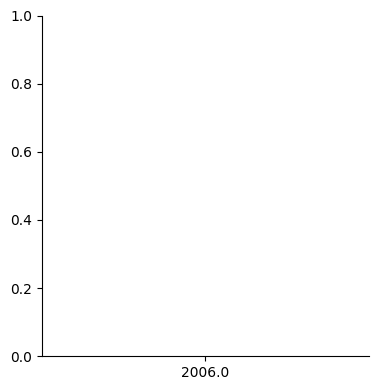

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    #col="PlotID",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

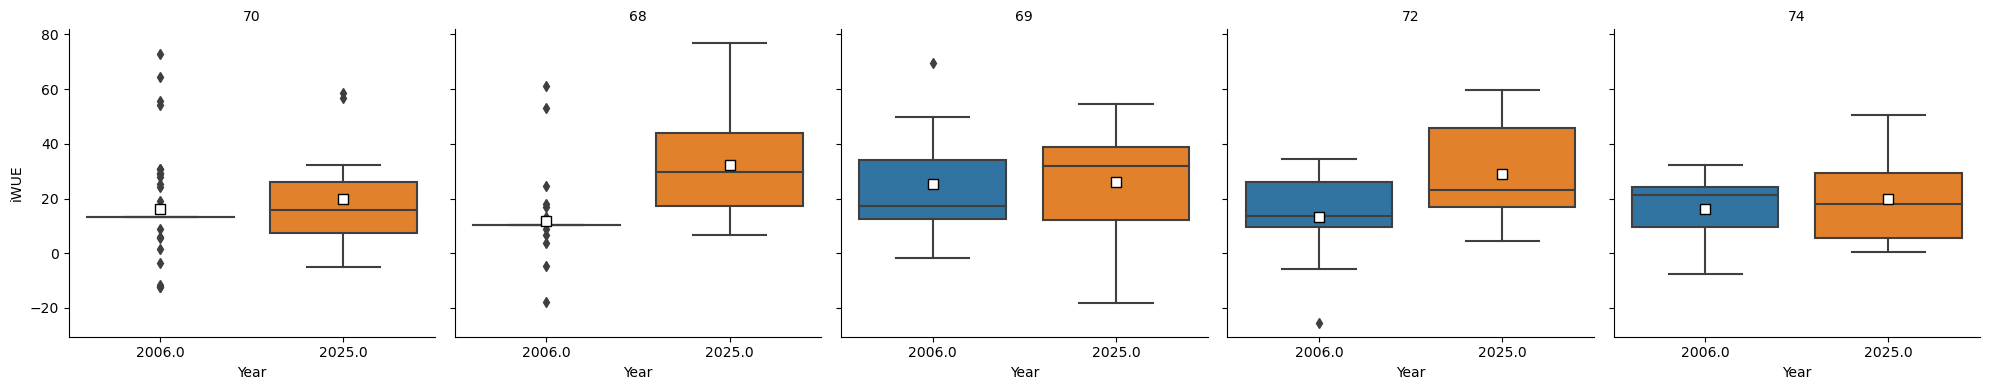

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df,
    x="Year",
    y= "iWUE (μmol/mol)",   # o el nombre exacto de tu columna
    col="Plot",     # facet por sitio
    kind="box",
    height=4,
    aspect=1
)

for ax in g.axes.flat:
    # obtener el valor de Elevation de este subplot
    plot = ax.get_title().split(" = ")[-1]

    subset = df[df["Plot"].astype(str) == plot]

    means = subset.groupby("Year")["iWUE (μmol/mol)"].mean()

    # posiciones en x (0,1,2,...)
    x_positions = range(len(means))

    ax.scatter(
        x_positions,
        means,
        color="white",
        edgecolor="black",
        marker="s",  # cuadrado
        s=60,
        zorder=5
    )


g.set_axis_labels("Year", "iWUE")
g.set_titles("{col_name}")  # título = nombre del sitio

plt.show()

In [ ]:
df["Site"]= "Selva Viva"
df["Elevation"] = 500
df = df.rename(columns={"Sample ID":"Sample-ID","treeID":"old_treeID","new ID 2024":"new_TreeID"})
df.to_excel("iWUE_SV.xlsx")